In [2]:
import numpy as np
import pandas as pd

path = '/Users/harishwar/Desktop/CFD/PINA-Harishwar/PINA-Harishwar/examples/problems/QGE/data/q_si.csv'
# Load the .npy files
data1 = np.load('final_zeta.npy')
reshaped_data1 = data1.reshape(-1, 3)
data2 = np.load('final_psi.npy')
reshaped_data2 = data2.reshape(-1, 3)

# Ensure both files have 3 columns
if reshaped_data1.shape[1] == 3 and reshaped_data2.shape[1] == 3:
    # Extract the last column from each file
    last_column1 = reshaped_data1[:, -1]
    last_column2 = reshaped_data2[:, -1]
    
    # Combine the two columns into a DataFrame
    combined_data = pd.DataFrame({'q': last_column1, 'si': last_column2})
    
    # Save to CSV
    combined_data.to_csv(path, index=False)
else:
    print("Both files need to have exactly 3 columns.")


In [3]:
import pandas as pd

data = np.load('final_zeta.npy')
reshaped_data = data.reshape(-1, 3)
df = pd.DataFrame(reshaped_data, columns=['x', 'y', 't'])

path1 = '/Users/harishwar/Desktop/CFD/PINA-Harishwar/PINA-Harishwar/examples/problems/QGE/data/input_xyt.csv'

# Split into two DataFrames
df_first_two_cols = df.iloc[:, :2]  # First two columns

# Load the original CSV file
df = df_first_two_cols

# Add a new column that increments by 0.01 for every 200 rows
df['t'] = (df.index // 200) * 0.01

# Save the updated DataFrame to a new CSV file
df.to_csv(path1, index=False)

print("File saved with an additional increment column as 'output_with_increment.csv'.")


File saved with an additional increment column as 'output_with_increment.csv'.


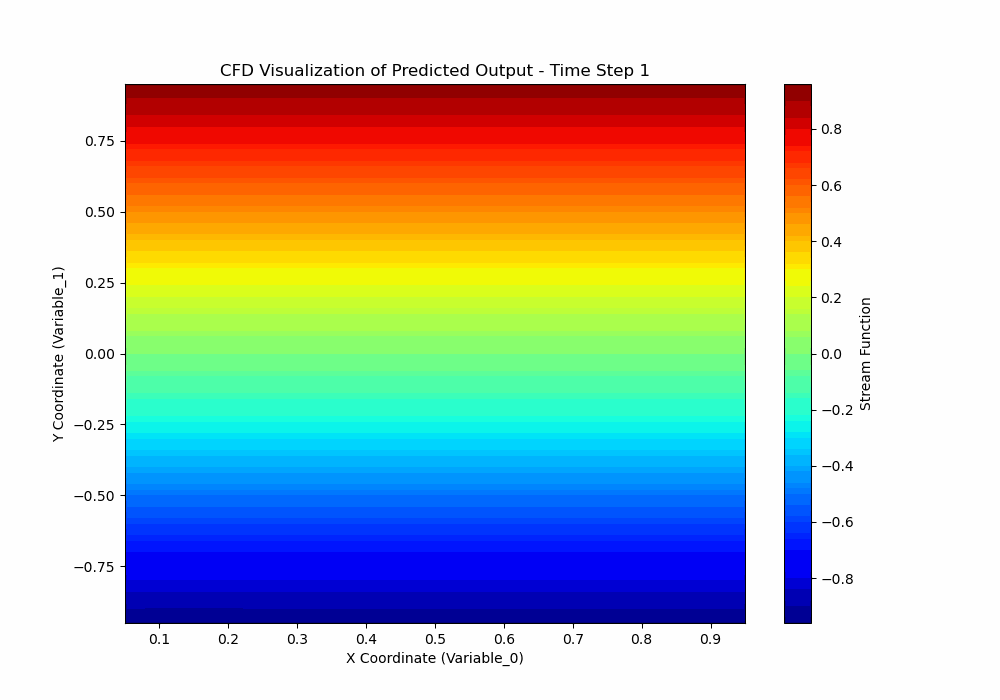

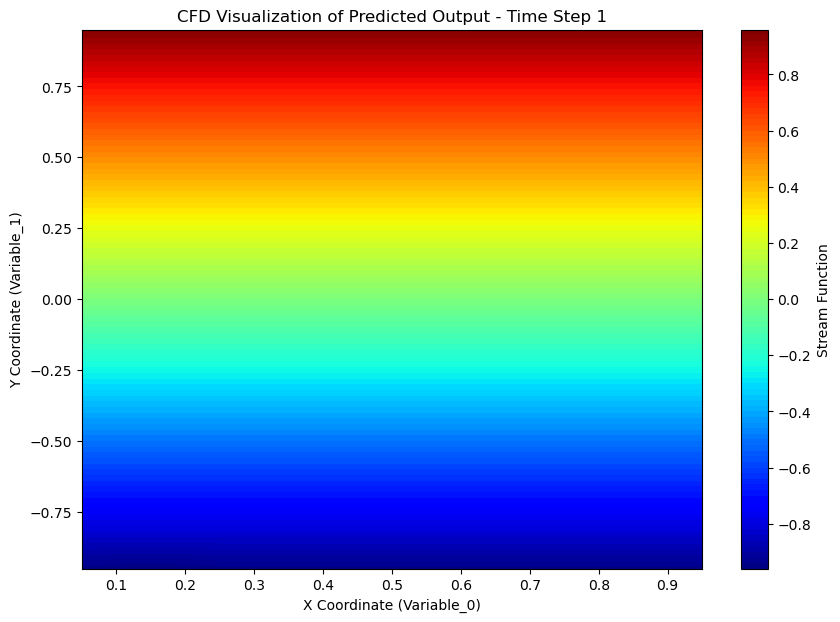

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from matplotlib.animation import FuncAnimation
import numpy as np
from PIL import Image

path = os.getcwd()

# Load the data
points_df = pd.read_csv('input_xyt.csv')
predicted_output_df = pd.read_csv('q_si.csv')
predicted_output_df_q = predicted_output_df.iloc[:, 0]

# Merge the dataframes if they are aligned by index
df = pd.concat([points_df, predicted_output_df_q], axis=1)

# Number of time steps (assuming 25 time steps)
num_time_steps = 100
num_points_per_step = len(df) // num_time_steps

# Set up the figure and axis for the animation
fig, ax = plt.subplots(figsize=(10, 7))

# Create contour plot for the first frame to determine levels for consistent color bar
start_idx = 0
end_idx = num_points_per_step
contour = ax.tricontourf(df['x'][start_idx:end_idx], 
                         df['y'][start_idx:end_idx], 
                         df['q'][start_idx:end_idx], 
                         levels=100, cmap='jet')

# Add the color bar once, outside the update function
cbar = plt.colorbar(contour, ax=ax)
cbar.set_label('Stream Function')

# Function to update each frame
def update(frame):
    ax.clear()  # Clear the previous frame
    start_idx = frame * num_points_per_step
    end_idx = (frame + 1) * num_points_per_step
    
    contour = ax.tricontourf(df['x'][start_idx:end_idx], 
                             df['y'][start_idx:end_idx], 
                             df['q'][start_idx:end_idx], 
                             levels=100, cmap='jet')
    
    ax.set_title(f'CFD Visualization of Predicted Output - Time Step {frame+1}')
    ax.set_xlabel('X Coordinate (Variable_0)')
    ax.set_ylabel('Y Coordinate (Variable_1)')
    # The color bar remains static, so no need to add it again

# Create animation using FuncAnimation
anim = FuncAnimation(fig, update, frames=num_time_steps, repeat=False)

# Save the animation as a GIF
gif_path = os.path.join(path, 'q_animation.gif')
anim.save(gif_path, writer='pillow', fps = 15)

# Display the GIF in Jupyter (or other environments)
from IPython.display import Image as IPImage
IPImage(filename=gif_path)


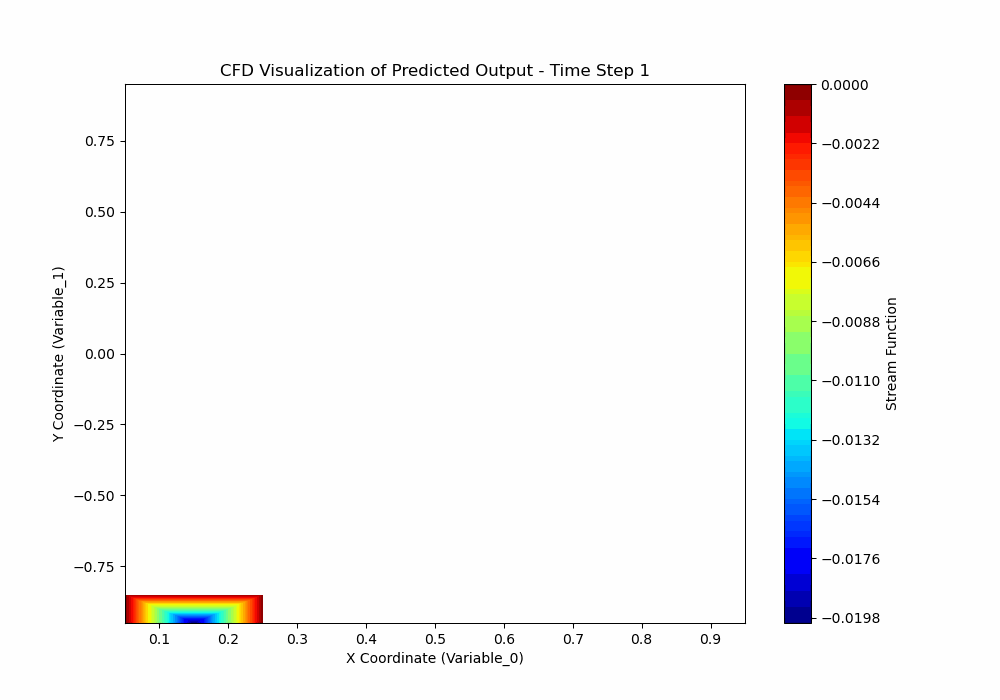

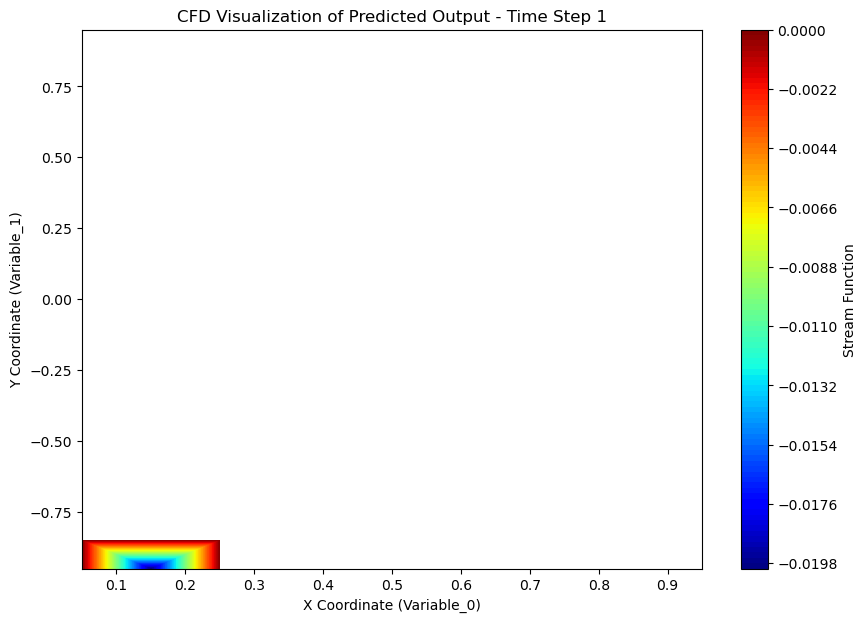

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from matplotlib.animation import FuncAnimation
import numpy as np
from PIL import Image

path = os.getcwd()

# Load the data
points_df = pd.read_csv('input_xyt.csv')
predicted_output_df = pd.read_csv('q_si.csv')
predicted_output_df_psi = predicted_output_df.iloc[:, 1]

# Merge the dataframes if they are aligned by index
df = pd.concat([points_df, predicted_output_df_psi], axis=1)

# Number of time steps (assuming 25 time steps)
num_time_steps = 100
num_points_per_step = len(df) // num_time_steps

# Set up the figure and axis for the animation
fig, ax = plt.subplots(figsize=(10, 7))

# Create contour plot for the first frame to determine levels for consistent color bar
start_idx = 0
end_idx = num_points_per_step
contour = ax.tricontourf(df['x'][start_idx:end_idx], 
                         df['y'][start_idx:end_idx], 
                         df['psi'][start_idx:end_idx], 
                         levels=100, cmap='jet')

# Add the color bar once, outside the update function
cbar = plt.colorbar(contour, ax=ax)
cbar.set_label('Stream Function')

# Function to update each frame
def update(frame):
    ax.clear()  # Clear the previous frame
    start_idx = frame * num_points_per_step
    end_idx = (frame + 1) * num_points_per_step
    
    contour = ax.tricontourf(df['x'][start_idx:end_idx], 
                             df['y'][start_idx:end_idx], 
                             df['psi'][start_idx:end_idx], 
                             levels=100, cmap='jet')
    
    ax.set_title(f'CFD Visualization of Predicted Output - Time Step {frame+1}')
    ax.set_xlabel('X Coordinate (Variable_0)')
    ax.set_ylabel('Y Coordinate (Variable_1)')
    # The color bar remains static, so no need to add it again

# Create animation using FuncAnimation
anim = FuncAnimation(fig, update, frames=num_time_steps, repeat=False)

# Save the animation as a GIF
gif_path = os.path.join(path, 'psi_animation.gif')
anim.save(gif_path, writer='pillow', fps = 8)

# Display the GIF in Jupyter (or other environments)
from IPython.display import Image as IPImage
IPImage(filename=gif_path)
